In [43]:
import pandas as pd

names = pd.read_csv('data/country-name.csv', skipinitialspace=True)
areas = pd.read_csv('data/country-area.csv', skipinitialspace=True)
iso   = pd.read_csv('data/iso-3166.csv', skipinitialspace=True)
pop   = pd.read_csv('data/country-population.csv', skipinitialspace=True)

# Normalise join key
names.columns = names.columns.str.strip()
areas.columns = areas.columns.str.strip()
iso.columns   = iso.columns.str.strip()
pop.columns   = pop.columns.str.strip()

print(names.shape, areas.shape, iso.shape, pop.shape)

(197, 3) (195, 3) (249, 5) (265, 2)


In [ ]:
# Merge all four tables on Alpha-3 code
df = (
    iso
    .merge(names.rename(columns={'alpha_3_code': 'alpha_3_code'}),
           on='alpha_3_code', how='left')
    .merge(areas.rename(columns={'alpha_3_code': 'alpha_3_code'}),
           on='alpha_3_code', how='left')
    .merge(pop, on='alpha_3_code', how='left')
)

df['total_area'] = df['Land'] + df['Water'].fillna(0)
df.head()

,english_short_name,french_short_name,alpha_2_code,alpha_3_code,numeric,common_english_name,official_country_name,Land,Water,population,total_area
0,Afghanistan,Afghanistan (l'),AF,AFG,4,Afghanistan,Islamic Republic of Afghanistan,652230.0,630.0,42647492.0,652860.0
1,Albania,Albanie (l'),AL,ALB,8,Albania,Republic of Albania,27400.0,330.0,2377128.0,27730.0
2,Algeria,Algérie (l'),DZ,DZA,12,Algeria,People's Democratic Republic of Algeria,2381741.0,0.0,46814308.0,2381741.0
3,American Samoa,Samoa américaines (les),AS,ASM,16,NaN,NaN,NaN,NaN,46765.0,NaN
4,Andorra,Andorre (l'),AD,AND,20,Andorra,Principality of Andorra,468.0,0.0,81938.0,468.0


In [45]:
# 10 largest countries by land area
df.nlargest(10, 'Land')[['english_short_name', 'alpha_3_code', 'Land', 'Water']]

,english_short_name,alpha_3_code,Land,Water
181,Russian Federation (the),RUS,16378410.0,719836.0
44,China,CHN,9326410.0,270550.0
235,United States of America (the),USA,9147593.0,685924.0
39,Canada,CAN,9093507.0,891163.0
30,Brazil,BRA,8460415.0,55352.0
12,Australia,AUS,7682300.0,58920.0
102,India,IND,2973190.0,314070.0
9,Argentina,ARG,2736690.0,43710.0
114,Kazakhstan,KAZ,2699700.0,25202.0
2,Algeria,DZA,2381741.0,0.0


In [46]:
# 10 smallest countries by land area (excluding zero/unknown)
df[df['Land'] > 0].nsmallest(10, 'Land')[['english_short_name', 'alpha_3_code', 'Land', 'Water']]

,english_short_name,alpha_3_code,Land,Water
145,Monaco,MCO,2.0,0.0
153,Nauru,NRU,21.0,0.0
228,Tuvalu,TUV,26.0,0.0
192,San Marino,SMR,61.0,0.0
127,Liechtenstein,LIE,160.0,0.0
137,Marshall Islands (the),MHL,181.0,0.0
186,Saint Kitts and Nevis,KNA,261.0,0.0
134,Maldives,MDV,298.0,0.0
136,Malta,MLT,316.0,0.0
87,Grenada,GRD,340.0,0.0


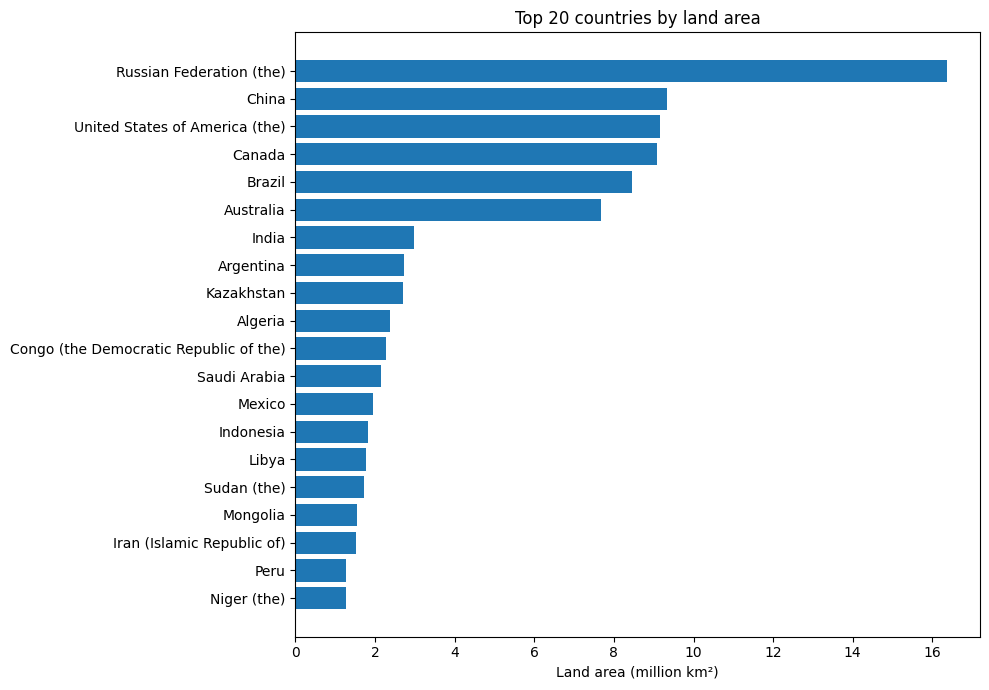

In [47]:
import matplotlib.pyplot as plt

top20 = df.nlargest(20, 'Land').sort_values('Land')

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(top20['english_short_name'], top20['Land'] / 1_000_000)
ax.set_xlabel('Land area (million km²)')
ax.set_title('Top 20 countries by land area')
plt.tight_layout()
plt.show()

## Population (2024)\nSource: World Bank SP.POP.TOTL

In [48]:
# 10 most populous countries (2024)
df.nlargest(10, 'population')[['english_short_name', 'alpha_3_code', 'population']]

,english_short_name,alpha_3_code,population
102,India,IND,1.450936e+09
44,China,CHN,1.408975e+09
235,United States of America (the),USA,3.401110e+08
103,Indonesia,IDN,2.834879e+08
167,Pakistan,PAK,2.512692e+08
160,Nigeria,NGA,2.326795e+08
30,Brazil,BRA,2.119986e+08
17,Bangladesh,BGD,1.735624e+08
181,Russian Federation (the),RUS,1.435339e+08
70,Ethiopia,ETH,1.320598e+08


In [49]:
# 10 least populous countries (2024, excluding zero/null)
df[df['population'] > 0].nsmallest(10, 'population')[['english_short_name', 'alpha_3_code', 'population']]

,english_short_name,alpha_3_code,population
228,Tuvalu,TUV,9646.0
153,Nauru,NRU,11947.0
168,Palau,PLW,17695.0
188,Saint Martin (French part),MAF,26129.0
192,San Marino,SMR,33977.0
137,Marshall Islands (the),MHL,37548.0
145,Monaco,MCO,38631.0
84,Gibraltar,GIB,39329.0
241,Virgin Islands (British),VGB,39471.0
127,Liechtenstein,LIE,40450.0


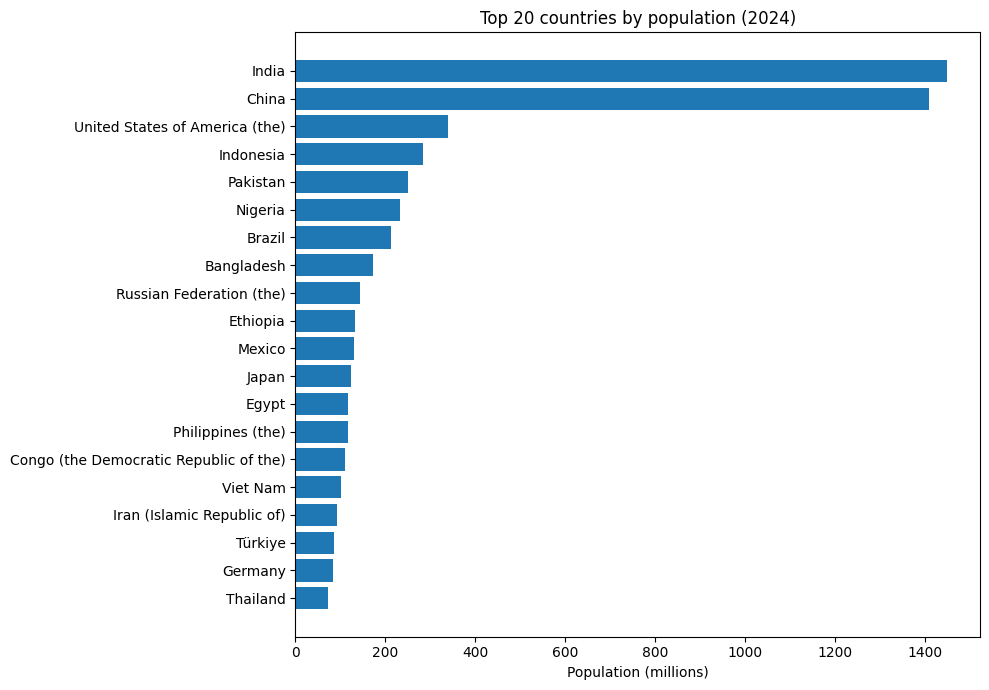

In [50]:
import matplotlib.pyplot as plt

top20_pop = df.nlargest(20, 'population').sort_values('population')

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(top20_pop['english_short_name'], top20_pop['population'] / 1_000_000)
ax.set_xlabel('Population (millions)')
ax.set_title('Top 20 countries by population (2024)')
plt.tight_layout()
plt.show()

In [51]:
# Population density (people per km² of land)
df['pop_density'] = df['population'] / df['Land']

df[df['Land'] > 0].nlargest(10, 'pop_density')[['english_short_name', 'alpha_3_code', 'population', 'Land', 'pop_density']].round(1)

,english_short_name,alpha_3_code,population,Land,pop_density
145,Monaco,MCO,38631.0,2.0,19315.5
199,Singapore,SGP,6036860.0,716.0,8431.4
16,Bahrain,BHR,1588670.0,778.0,2042.0
136,Malta,MLT,568847.0,316.0,1800.1
134,Maldives,MDV,527799.0,298.0,1771.1
17,Bangladesh,BGD,173562364.0,130170.0,1333.4
169,"Palestine, State of",PSE,5289152.0,6000.0,881.5
18,Barbados,BRB,282467.0,431.0,655.4
140,Mauritius,MUS,1245779.0,2030.0,613.7
182,Rwanda,RWA,14256567.0,24668.0,577.9


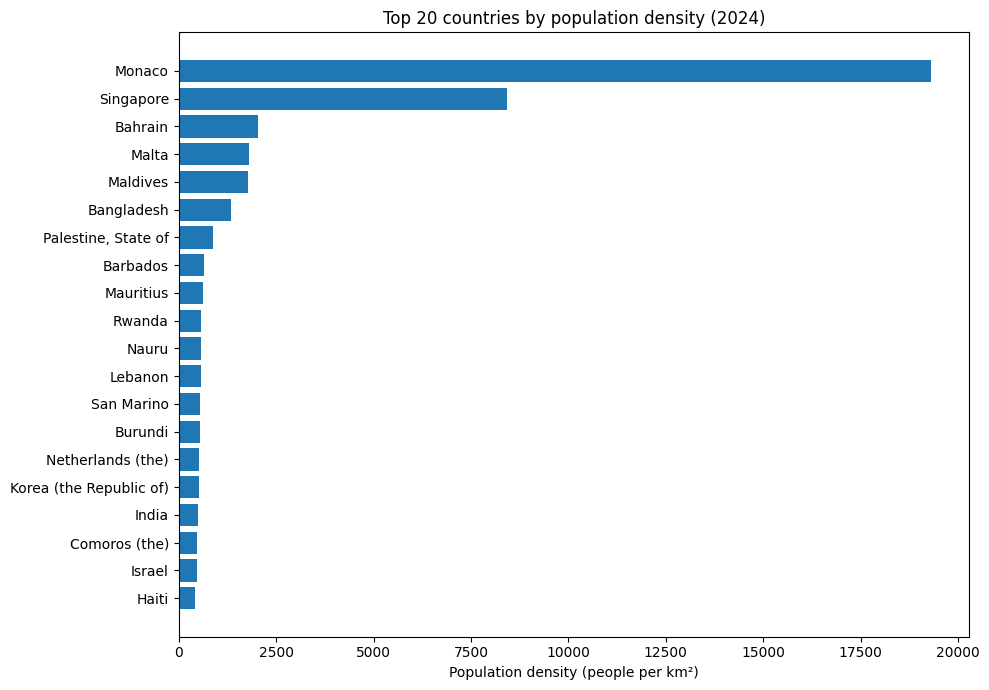

In [52]:
top20_density = df[df['Land'] > 0].nlargest(20, 'pop_density').sort_values('pop_density')

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(top20_density['english_short_name'], top20_density['pop_density'])
ax.set_xlabel('Population density (people per km²)')
ax.set_title('Top 20 countries by population density (2024)')
plt.tight_layout()
plt.show()

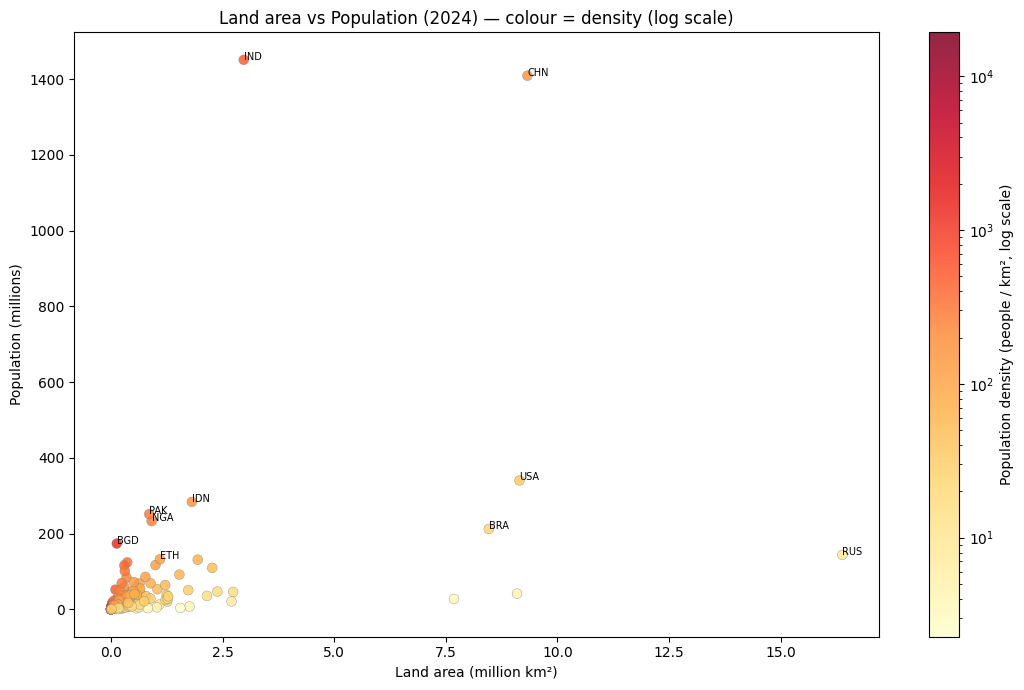

In [53]:
import matplotlib.colors as mcolors

plot_df = df[df['Land'] > 0].dropna(subset=['population', 'pop_density']).copy()

norm = mcolors.LogNorm(vmin=plot_df['pop_density'].min(), vmax=plot_df['pop_density'].max())

fig, ax = plt.subplots(figsize=(11, 7))
sc = ax.scatter(
    plot_df['Land'] / 1_000_000,
    plot_df['population'] / 1_000_000,
    c=plot_df['pop_density'],
    cmap='YlOrRd',
    norm=norm,
    s=50,
    alpha=0.85,
    edgecolors='grey',
    linewidths=0.3
)
plt.colorbar(sc, ax=ax, label='Population density (people / km², log scale)')
ax.set_xlabel('Land area (million km²)')
ax.set_ylabel('Population (millions)')
ax.set_title('Land area vs Population (2024) — colour = density (log scale)')

for _, row in plot_df.nlargest(10, 'population').iterrows():
    ax.annotate(row['alpha_3_code'],
                xy=(row['Land'] / 1_000_000, row['population'] / 1_000_000),
                fontsize=7, ha='left')

plt.tight_layout()
plt.show()